# 04 · Customers: Retention, Cohorts & RFM Segmentation

**Business question:** *Do customers come back? Why not? Which customers should marketing focus on?*

**New skills today**
- **Cohort analysis**: the standard way companies measure retention
- `date_trunc`, month differences, **self-joins**
- `NTILE()` for scoring, and **RFM segmentation**
- Annotated heatmaps & grouped bar charts

In [1]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")
from chart_style import apply_style, save, COLORS
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "olist.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()

# same definition as Day 3: valid orders inside the analysis window
con.execute("""
    CREATE OR REPLACE TEMP VIEW orders AS
    SELECT * FROM marts.fct_orders
    WHERE in_analysis_window AND order_status NOT IN ('canceled', 'unavailable')
""");

## 1. How many customers come back?

In [2]:
dist = sql("""
    WITH per_customer AS (
        SELECT customer_unique_id, COUNT(*) AS orders
        FROM orders
        GROUP BY customer_unique_id
    )
    SELECT CASE WHEN orders >= 4 THEN '4+' ELSE CAST(orders AS VARCHAR) END AS orders_placed,
           COUNT(*)                                             AS customers,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)   AS pct_customers
    FROM per_customer
    GROUP BY orders_placed
    ORDER BY orders_placed
""")
dist

,orders_placed,customers,pct_customers
0,1,91832,96.96
1,2,2640,2.79
2,3,187,0.20
3,4+,48,0.05


**~97% of customers ordered exactly once.** For comparison, e-commerce businesses typically aim for repeat rates of 20–30%+.
But before we trust the ~3% number, let's check *how* people come back.

## 2. ⚠️ The same-day trap: are repeat orders real?
We compare each customer's **1st** and **2nd** order using a **self-join**: joining a table *to itself*.
Here `a` is the first order and `b` is the second order of the same customer (`customer_order_number` from Day 2 makes this easy).

In [3]:
gaps = sql("""
    SELECT a.customer_unique_id,
           date_diff('day', a.purchased_at, b.purchased_at) AS days_to_second_order
    FROM orders a
    JOIN orders b
      ON a.customer_unique_id = b.customer_unique_id
     AND a.customer_order_number = 1
     AND b.customer_order_number = 2
""")
total_customers = sql("SELECT COUNT(DISTINCT customer_unique_id) AS n FROM orders").n[0]
same_day = (gaps["days_to_second_order"] == 0).sum()
true_repeat = (gaps["days_to_second_order"] > 0).sum()

print(f"Customers with a 2nd order:            {len(gaps):,}  ({100*len(gaps)/total_customers:.1f}% of customers)")
print(f"...placed on the SAME day as the 1st:  {same_day:,}  ({100*same_day/len(gaps):.0f}% of them)")
print(f"True repeat customers (came back later): {true_repeat:,}  ({100*true_repeat/total_customers:.1f}% of customers)")
print(f"Median days to a genuine 2nd order:    {gaps[gaps.days_to_second_order > 0].days_to_second_order.median():.0f}")

Customers with a 2nd order:            2,863  (3.0% of customers)
...placed on the SAME day as the 1st:  865  (30% of them)
True repeat customers (came back later): 1,998  (2.1% of customers)
Median days to a genuine 2nd order:    75


**Finding:** about **30% of "repeat" customers placed their 2nd order the same day**. That's probably a split basket (e.g. items from different sellers checked out separately),
not loyalty. **The true repeat rate is about 2%.** Always sanity-check a metric before reporting it, because this is exactly what interviewers love to hear.

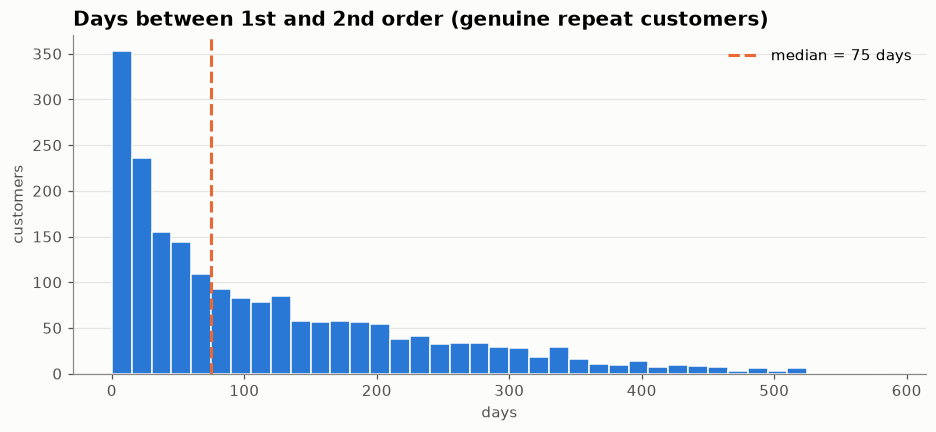

In [4]:
real = gaps[gaps["days_to_second_order"] > 0]["days_to_second_order"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(real, bins=range(0, 600, 15), color=COLORS["blue"], edgecolor="#fcfcfb")
ax.axvline(real.median(), color=COLORS["orange"], linestyle="--", label=f"median = {real.median():.0f} days")
ax.set_title("Days between 1st and 2nd order (genuine repeat customers)")
ax.set_xlabel("days"); ax.set_ylabel("customers")
ax.legend()
save(fig, "07_days_to_second_order")
plt.show()

## 3. Cohort retention analysis
A **cohort** = customers grouped by the month of their **first** purchase. For each cohort we ask:
*what % of them bought again 1, 2, 3… months later?* This separates "are we keeping customers?" from "are we acquiring more?"

Step by step:
1. `cohorts`: each customer's first-purchase month (`date_trunc('month', ...)` turns 2017-03-17 into 2017-03-01)
2. `activity`: every month in which each customer bought
3. join them and compute `month_number` = months since first purchase (0 = the first month itself)

In [5]:
cohort_long = sql("""
    WITH cohorts AS (
        SELECT customer_unique_id,
               date_trunc('month', MIN(purchased_at)) AS cohort_month
        FROM orders
        GROUP BY customer_unique_id
    ),
    activity AS (
        SELECT DISTINCT customer_unique_id,
               date_trunc('month', purchased_at) AS active_month
        FROM orders
    ),
    joined AS (
        SELECT c.cohort_month,
               date_diff('month', c.cohort_month, a.active_month) AS month_number,
               c.customer_unique_id
        FROM cohorts c
        JOIN activity a ON c.customer_unique_id = a.customer_unique_id
    )
    SELECT strftime(cohort_month, '%Y-%m')      AS cohort,
           month_number,
           COUNT(DISTINCT customer_unique_id)   AS customers
    FROM joined
    GROUP BY cohort, month_number
    ORDER BY cohort, month_number
""")
cohort_long.head(8)

,cohort,month_number,customers
0,2017-01,0,753
1,2017-01,1,3
2,2017-01,2,2
3,2017-01,3,1
4,2017-01,4,3
5,2017-01,5,1
6,2017-01,6,3
7,2017-01,7,1


That's a **long** table (one row per cohort × month). `pivot` turns it into the classic cohort grid.
Then divide each row by its month-0 size to get **retention %**.

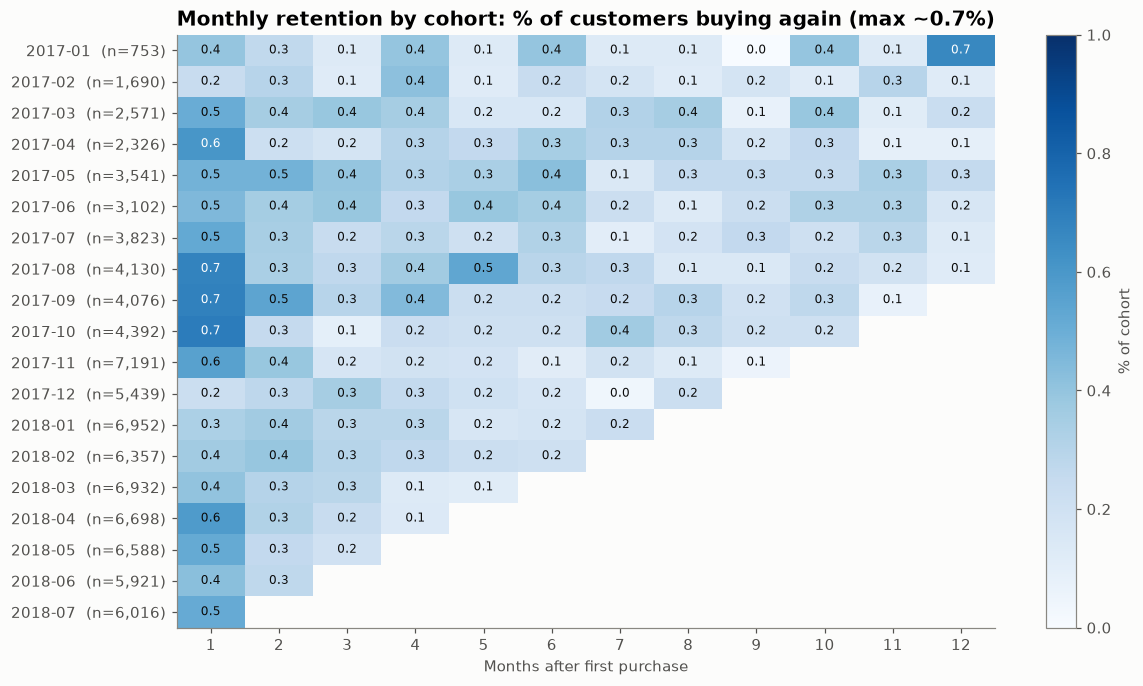

In [6]:
counts = cohort_long.pivot(index="cohort", columns="month_number", values="customers")
cohort_size = counts[0]
retention = counts.div(cohort_size, axis=0) * 100        # divide every row by its cohort size

grid = retention.loc["2017-01":"2018-07", 1:12].copy()    # cohorts with enough history, months 1-12
# a missing value means "0 customers came back", unless that month is still in the future (after Aug 2018)
for cohort in grid.index:
    months_available = (2018 - int(cohort[:4])) * 12 + (8 - int(cohort[5:]))
    for m in grid.columns:
        if m <= months_available and np.isnan(grid.loc[cohort, m]):
            grid.loc[cohort, m] = 0.0
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(grid, cmap="Blues", aspect="auto", vmin=0, vmax=1)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.6 else "#0b0b0b")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels([f"{c}  (n={int(cohort_size[c]):,})" for c in grid.index])
ax.set_xlabel("Months after first purchase"); ax.grid(False)
ax.set_title("Monthly retention by cohort: % of customers buying again (max ~0.7%)")
fig.colorbar(im, ax=ax, label="% of cohort")
save(fig, "08_cohort_retention")
plt.show()

**How to read it:** row 2017-05 = the 3,541 customers whose first purchase was in May 2017; the cell under "3" = % of them who bought again 3 months later.

**Finding:** in **every** cohort, well **under 1%** of customers buy again in any given month, and this doesn't improve over time.
Low retention is **structural**, not caused by one bad period. (Empty cells at the bottom right = months that haven't happened yet.)

In [7]:
# cumulative: what % of each cohort came back at least once within 6 months?
within6 = sql("""
    WITH cohorts AS (
        SELECT customer_unique_id, MIN(purchased_at) AS first_at
        FROM orders GROUP BY customer_unique_id
    )
    SELECT strftime(c.first_at, '%Y-%m')  AS cohort,
           COUNT(DISTINCT c.customer_unique_id) AS customers,
           ROUND(100.0 * COUNT(DISTINCT CASE WHEN o.purchased_at > c.first_at + INTERVAL 1 DAY
                                              AND o.purchased_at <= c.first_at + INTERVAL 180 DAY
                                             THEN c.customer_unique_id END)
                 / COUNT(DISTINCT c.customer_unique_id), 2) AS pct_returned_within_6m
    FROM cohorts c
    JOIN orders o ON c.customer_unique_id = o.customer_unique_id
    WHERE c.first_at < '2018-03-01'          -- only cohorts with a full 6 months of history
    GROUP BY cohort ORDER BY cohort
""")
print(f"Average: {within6.pct_returned_within_6m.mean():.1f}% of customers return within 6 months (excluding same-day orders)")
within6

Average: 2.0% of customers return within 6 months (excluding same-day orders)


,cohort,customers,pct_returned_within_6m
0,2017-01,753,1.73
1,2017-02,1690,1.66
2,2017-03,2571,1.83
3,2017-04,2326,1.98
4,2017-05,3541,2.40
5,2017-06,3102,2.26
6,2017-07,3823,2.01
7,2017-08,4130,2.47
8,2017-09,4076,2.53
9,2017-10,4392,1.68


## 4. Does the first experience affect coming back?
If a customer's first order goes badly (late delivery, low review), are they less likely to return?

In [8]:
first_exp = sql("""
    SELECT o.is_late,
           COUNT(*)                                         AS customers,
           ROUND(100.0 * AVG(CASE WHEN c.total_orders > 1 THEN 1 ELSE 0 END), 2) AS repeat_rate_pct
    FROM orders o
    JOIN marts.dim_customers c ON o.customer_unique_id = c.customer_unique_id
    WHERE o.customer_order_number = 1 AND o.is_late IS NOT NULL
    GROUP BY o.is_late
""")
first_exp

,is_late,customers,repeat_rate_pct
0,False,86640,3.12
1,True,6343,2.57


**Finding:** customers whose **first delivery was late** come back **less often** (about 2.5% vs 3.1%, a ~20% relative drop).
Is that difference real or just chance? We'll test it statistically on Day 5.

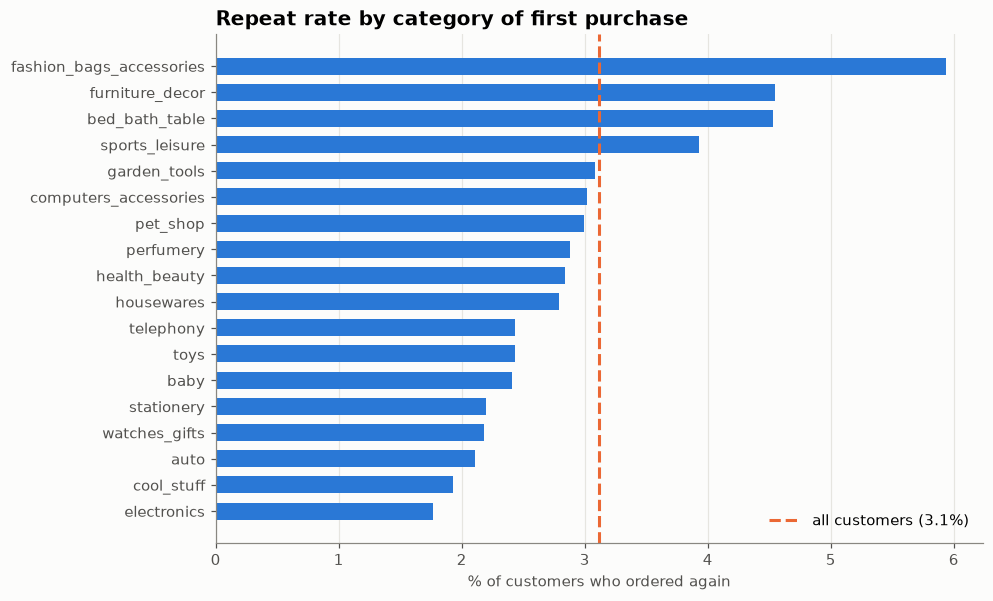

In [9]:
by_cat = sql("""
    WITH first_item AS (           -- category of the first item in each customer's first order
        SELECT o.customer_unique_id, p.category
        FROM orders o
        JOIN marts.fct_order_items i ON o.order_id = i.order_id AND i.order_item_id = 1
        JOIN marts.dim_products   p ON i.product_id = p.product_id
        WHERE o.customer_order_number = 1
    )
    SELECT f.category,
           COUNT(*)                                                   AS customers,
           ROUND(100.0 * AVG(CASE WHEN c.total_orders > 1 THEN 1 ELSE 0 END), 2) AS repeat_rate_pct
    FROM first_item f
    JOIN marts.dim_customers c ON f.customer_unique_id = c.customer_unique_id
    GROUP BY f.category
    HAVING COUNT(*) >= 1500        -- ignore tiny categories (unreliable rates)
    ORDER BY repeat_rate_pct DESC
""")
overall = 100 * (sql("SELECT AVG(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS r FROM marts.dim_customers").r[0])

plot = by_cat.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot["category"], plot["repeat_rate_pct"], color=COLORS["blue"], height=0.65)
ax.axvline(overall, color=COLORS["orange"], linestyle="--", label=f"all customers ({overall:.1f}%)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("% of customers who ordered again")
ax.set_title("Repeat rate by category of first purchase")
ax.legend(loc="lower right")
save(fig, "09_repeat_by_category")
plt.show()

**Finding:** customers who start with **fashion bags, furniture/decor and bed/bath/table** come back most (4.5–6%),
while **electronics, cool stuff, auto and watches/gifts** buyers rarely return (~2%).
→ Target retention campaigns (e.g. "complete the room" recommendations) at home & fashion first-time buyers.

## 5. RFM segmentation
RFM scores each customer on:
- **R**ecency: days since last order (recent = better)
- **F**requency: number of orders
- **M**onetary: total spend

`NTILE(5) OVER (ORDER BY x)` splits customers into **5 equal-sized groups** (quintiles) ordered by x and labels them 1–5.

⚠️ Textbook RFM scores F in quintiles too. That's impossible here: 97% have F = 1. So we score **R and M with NTILE(5)** and use **F = 1 vs 2+**.
Adapting a method to your data (and explaining why) is what separates analysts from tutorial-followers.

In [10]:
rfm = sql("""
    WITH base AS (
        SELECT customer_unique_id,
               date_diff('day', MAX(purchased_at), TIMESTAMP '2018-09-01') AS recency_days,
               COUNT(*)                                                    AS frequency,
               SUM(order_revenue)                                          AS monetary
        FROM orders
        GROUP BY customer_unique_id
    )
    SELECT *,
           NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
           NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
    FROM base
""")
# check the scores make sense: each score = 20% of customers, with increasing spend
rfm.groupby("m_score")["monetary"].agg(["count", "min", "max", "mean"]).round(1)

,count,min,max,mean
m_score,,,,
1,18942,9.6,55.3,39.7
2,18942,55.3,87.5,70.6
3,18941,87.5,133.0,108.7
4,18941,133.0,209.0,165.5
5,18937,209.0,13664.1,443.7


Now turn scores into **named segments** that marketing can act on:

| Segment | Rule | Action |
|---|---|---|
| Champions | 2+ orders, recent | reward, referral program |
| Loyal (lapsing) | 2+ orders, not recent | personalised win-back |
| New big spenders | 1 order, recent, top-40% spend | nurture into 2nd purchase |
| New customers | 1 order, recent | welcome series |
| Needs attention | 1 order, middle recency | reminder offers |
| At risk: big spenders | 1 order, long ago, top-40% spend | high-value win-back |
| Lost / one-off | 1 order, long ago, low spend | low-cost or no spend |

The production version of this logic lives in **`sql/marts/customer_rfm.sql`** (built by `build_models.py`), so the dashboard can reuse it.

In [11]:
segments = sql("""
    SELECT segment,
           COUNT(*)                                                 AS customers,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)       AS pct_customers,
           ROUND(SUM(monetary))                                     AS revenue,
           ROUND(100.0 * SUM(monetary) / SUM(SUM(monetary)) OVER (), 1) AS pct_revenue,
           ROUND(AVG(monetary))                                     AS avg_spend,
           ROUND(AVG(recency_days))                                 AS avg_days_since_order
    FROM marts.customer_rfm
    GROUP BY segment
    ORDER BY revenue DESC
""")
segments

,segment,customers,pct_customers,revenue,pct_revenue,avg_spend,avg_days_since_order
0,New big spenders,14595,15.4,4422550.0,28.2,303.0,94.0
1,At risk: big spenders,13957,14.7,4306930.0,27.5,309.0,395.0
2,Needs attention,18328,19.4,2790410.0,17.8,152.0,223.0
3,Lost / one-off,22894,24.2,1665656.0,10.6,73.0,397.0
4,New customers,22058,23.3,1611889.0,10.3,73.0,92.0
5,Loyal (lapsing),1646,1.7,490727.0,3.1,298.0,323.0
6,Champions,1229,1.3,395544.0,2.5,322.0,91.0


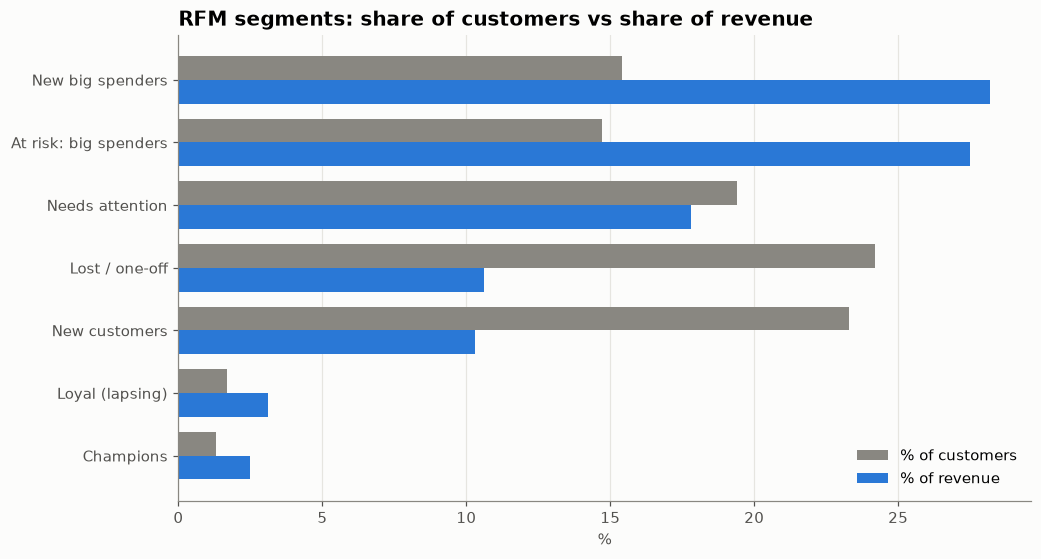

In [12]:
plot = segments.iloc[::-1]
y = np.arange(len(plot))
h = 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(y + h/2, plot["pct_customers"], height=h, color=COLORS["grey"], label="% of customers")
ax.barh(y - h/2, plot["pct_revenue"],   height=h, color=COLORS["blue"], label="% of revenue")
ax.set_yticks(y); ax.set_yticklabels(plot["segment"])
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("%")
ax.set_title("RFM segments: share of customers vs share of revenue")
ax.legend(loc="lower right")
save(fig, "10_rfm_segments")
plt.show()

**Findings**
- Two segments, **New big spenders** and **At risk: big spenders**, are ~30% of customers but **~56% of revenue**.
- **At risk: big spenders** (~14k customers, avg spend ~R$ 309, last order over a year ago) are the most valuable win-back target.
- Repeat customers (Champions + Loyal) are only ~3% of customers and ~6% of revenue. Retention is not currently a revenue driver.

---
## ✏️ Your turn
Answers in `LEARNING_NOTES.md`.
1. How many customers placed **3 or more** orders? (hint: `marts.dim_customers`, `total_orders`)
2. From `marts.customer_rfm`: the average `recency_days` and `monetary` for each `r_score` (1–5).
3. `NTILE` practice: split customers into **4** spending groups (quartiles) and show the min and max `monetary` of each.

In [ ]:
# 1. customers with 3+ orders

In [ ]:
# 2. avg recency and monetary by r_score

In [ ]:
# 3. spending quartiles with NTILE(4)

---
## Summary: key findings (Customers)
| # | Finding | So what? |
|---|---|---|
| 1 | **97% of customers order only once**; ~30% of "repeat" orders are same-day split baskets → **true repeat rate ≈ 2%** | Growth depends almost entirely on new-customer acquisition |
| 2 | Retention is **below 1% per month in every cohort** and not improving | Structural problem, not a one-off |
| 3 | Genuine repeat buyers return after a **median ~2–3 months** | Time win-back messages ~60–90 days after purchase |
| 4 | **Late first delivery → ~20% lower repeat rate** (2.5% vs 3.1%) | Delivery reliability affects retention (tested on Day 5) |
| 5 | Home & fashion first-time buyers repeat ~2–3× more than electronics buyers | Focus retention programs on those categories |
| 6 | "New big spenders" + "At risk: big spenders" = ~30% of customers, **~56% of revenue** | Prioritise these two segments for CRM spend |

**Recommendations:** (1) a post-purchase email/push journey timed at 30–90 days with category-based recommendations;
(2) a win-back campaign for the ~14k *At risk: big spenders*; (3) fix late deliveries on first orders; (4) track true repeat rate (excluding same-day orders) as a KPI.

Next (Day 5): **delivery performance & sellers**, plus our first statistical tests.

In [ ]:
con.close()